<a href="https://colab.research.google.com/github/anushkasinghania/Breast-Cancer-Detection-using-ResUNet/blob/main/Breast_Cancer_Detection_ResUnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")
%matplotlib inline
import gc

from tqdm.notebook import trange, tqdm

from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Dropout, concatenate, UpSampling2D
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras import backend as K


import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *

import random

## Seeding
seed = 2019
random.seed = seed
np.random.seed = seed
tf.seed = seed


In [ ]:
w, h = 304,304
border = 5

In [ ]:
ids = next(os.walk("/content/drive/MyDrive/ResUnet/dataset/train/images"))[2] # list of names all images in the given path
print("No. of images = ", len(ids))

No. of images =  50


Data Reading and Train test split

In [ ]:
import glob
train = sorted(glob.glob("/content/drive/MyDrive/ResUnet/dataset/train/images/*"))
train_mask = sorted(glob.glob("/content/drive/MyDrive/ResUnet/dataset/train/masks/*.png"))[:64]
print(f'Total Train Images : {len(train)}\nTotal Mask Image : {len(train_mask)}')

Total Train Images : 50
Total Mask Image : 50


In [ ]:
X = np.zeros((len(train), h, w, 3), dtype=np.float32)
y = np.zeros((len(train_mask), h, w, 1), dtype=np.float32)

In [ ]:
for n, (img, mimg) in tqdm(enumerate(zip(train, train_mask))):
  # print(n, img, mimg)
  # Load images
  img = load_img(img)
  x_img = img_to_array(img)
  x_img = resize(x_img, (h, w, 3), mode = 'constant', preserve_range = True)
  # # Load masks
  mask = img_to_array(load_img(mimg, color_mode = "grayscale"))
  mask = resize(mask, (h, w, 1), mode = 'constant', preserve_range = True)
  # # Save images
  X[n] = x_img/255.0
  y[n] = mask/255.0

0it [00:00, ?it/s]

In [ ]:
print(X.shape, y.shape)

(50, 304, 304, 3) (50, 304, 304, 1)


In [ ]:
# Split train and valid
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
gc.collect()

(45, 304, 304, 3) (45, 304, 304, 1) (5, 304, 304, 3) (5, 304, 304, 1)


134

Visualization the image and It masks

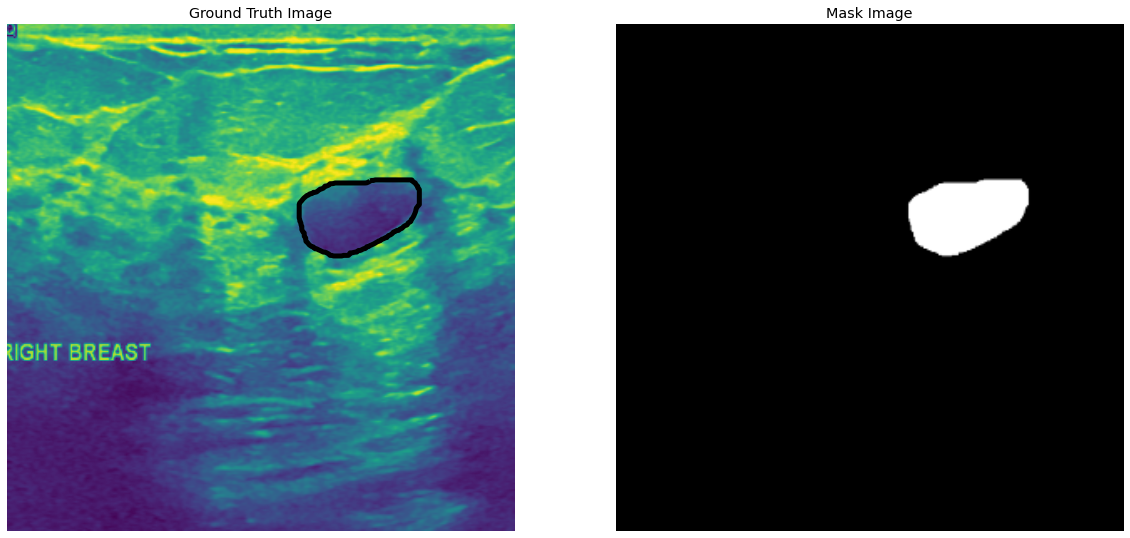

In [ ]:
p# Visualize any randome image along with the mask
ix = random.randint(0, len(X_train))
has_mask = y_train[ix].max() > 0 # salt indicator

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20, 15))

ax1.imshow(X_train[ix, ..., 0], interpolation = 'bilinear')
if has_mask: # if salt
    # draw a boundary(contour) in the original image separating salt and non-salt areas
    ax1.contour(y_train[ix].squeeze(), colors = 'k', linewidths = 5, levels = [0.5])
ax1.set_title('Ground Truth Image')
ax1.set_axis_off()
ax2.imshow(y_train[ix].squeeze(), cmap = 'gray', interpolation = 'bilinear')
ax2.set_title('Mask Image')
ax2.set_axis_off()

In [ ]:
def batch_Norm_Activation(x, BN=False): ## To Turn off Batch Normalization, Change BN to False >
    if BN == True:
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
    else:
        x= Activation("relu")(x)
    return x


def ResUnet(image_size):
    inputs = Input(shape=(image_size, image_size, 3))
    filters = 16

    # Encoder
    conv = Conv2D(filters*1, kernel_size= (3,3), padding= 'same', strides= (1,1))(inputs)
    conv = batch_Norm_Activation(conv)
    conv = Conv2D(filters*1, kernel_size= (3,3), padding= 'same', strides= (1,1))(conv)
    shortcut = Conv2D(filters*1, kernel_size=(1,1), padding='same', strides=(1,1))(inputs)
    shortcut = batch_Norm_Activation(shortcut)
    output1 = add([conv, shortcut])

    res1 = batch_Norm_Activation(output1)
    res1 = Conv2D(filters*2, kernel_size= (3,3), padding= 'same', strides= (2,2))(res1)
    res1 = batch_Norm_Activation(res1)
    res1 = Conv2D(filters*2, kernel_size= (3,3), padding= 'same', strides= (1,1))(res1)
    shortcut1 = Conv2D(filters*2, kernel_size= (3,3), padding='same', strides=(2,2))(output1)
    shortcut1 = batch_Norm_Activation(shortcut1)
    output2 = add([shortcut1, res1])

    res2 = batch_Norm_Activation(output2)
    res2 = Conv2D(filters*4, kernel_size= (3,3), padding= 'same', strides= (2,2))(res2)
    res2 = batch_Norm_Activation(res2)
    res2 = Conv2D(filters*4, kernel_size= (3,3), padding= 'same', strides= (1,1))(res2)
    shortcut2 = Conv2D(filters*4, kernel_size= (3,3), padding='same', strides=(2,2))(output2)
    shortcut2 = batch_Norm_Activation(shortcut2)
    output3 = add([shortcut2, res2])

    res3 = batch_Norm_Activation(output3)
    res3 = Conv2D(filters*8, kernel_size= (3,3), padding= 'same', strides= (2,2))(res3)
    res3 = batch_Norm_Activation(res3)
    res3 = Conv2D(filters*8, kernel_size= (3,3), padding= 'same', strides= (1,1))(res3)
    shortcut3 = Conv2D(filters*8, kernel_size= (3,3), padding='same', strides=(2,2))(output3)
    shortcut3 = batch_Norm_Activation(shortcut3)
    output4 = add([shortcut3, res3])

    res4 = batch_Norm_Activation(output4)
    res4 = Conv2D(filters*16, kernel_size= (3,3), padding= 'same', strides= (2,2))(res4)
    res4 = batch_Norm_Activation(res4)
    res4 = Conv2D(filters*16, kernel_size= (3,3), padding= 'same', strides= (1,1))(res4)
    shortcut4 = Conv2D(filters*16, kernel_size= (3,3), padding='same', strides=(2,2))(output4)
    shortcut4 = batch_Norm_Activation(shortcut4)
    output5 = add([shortcut4, res4])

    #bridge
    conv = batch_Norm_Activation(output5)
    conv = Conv2D(filters*16, kernel_size= (3,3), padding= 'same', strides= (1,1))(conv)
    conv = batch_Norm_Activation(conv)
    conv = Conv2D(filters*16, kernel_size= (3,3), padding= 'same', strides= (1,1))(conv)

    #decoder

    uconv1 = UpSampling2D((2,2))(conv)
    uconv1 = concatenate([uconv1, output4])

    uconv11 = batch_Norm_Activation(uconv1)
    uconv11 = Conv2D(filters*16, kernel_size= (3,3), padding= 'same', strides=(1,1))(uconv11)
    uconv11 = batch_Norm_Activation(uconv11)
    uconv11 = Conv2D(filters*16, kernel_size= (3,3), padding= 'same', strides=(1,1))(uconv11)
    shortcut5 = Conv2D(filters*16, kernel_size= (3,3), padding='same', strides=(1,1))(uconv1)
    shortcut5 = batch_Norm_Activation(shortcut5)
    output6 = add([uconv11,shortcut5])

    uconv2 = UpSampling2D((2,2))(output6)
    uconv2 = concatenate([uconv2, output3])

    uconv22 = batch_Norm_Activation(uconv2)
    uconv22 = Conv2D(filters*8, kernel_size= (3,3), padding= 'same', strides=(1,1))(uconv22)
    uconv22 = batch_Norm_Activation(uconv22)
    uconv22 = Conv2D(filters*8, kernel_size= (3,3), padding= 'same', strides=(1,1))(uconv22)
    shortcut6 = Conv2D(filters*8, kernel_size= (3,3), padding='same', strides=(1,1))(uconv2)
    shortcut6 = batch_Norm_Activation(shortcut6)
    output7 = add([uconv22,shortcut6])

    uconv3 = UpSampling2D((2,2))(output7)
    uconv3 = concatenate([uconv3, output2])

    uconv33 = batch_Norm_Activation(uconv3)
    uconv33 = Conv2D(filters*4, kernel_size= (3,3), padding= 'same', strides=(1,1))(uconv33)
    uconv33 = batch_Norm_Activation(uconv33)
    uconv33 = Conv2D(filters*4, kernel_size= (3,3), padding= 'same', strides=(1,1))(uconv33)
    shortcut7 = Conv2D(filters*4, kernel_size= (3,3), padding='same', strides=(1,1))(uconv3)
    shortcut7 = batch_Norm_Activation(shortcut7)
    output8 = add([uconv33,shortcut7])

    uconv4 = UpSampling2D((2,2))(output8)
    uconv4 = concatenate([uconv4, output1])

    uconv44 = batch_Norm_Activation(uconv4)
    uconv44 = Conv2D(filters*2, kernel_size= (3,3), padding= 'same', strides=(1,1))(uconv44)
    uconv44 = batch_Norm_Activation(uconv44)
    uconv44 = Conv2D(filters*2, kernel_size= (3,3), padding= 'same', strides=(1,1))(uconv44)
    shortcut8 = Conv2D(filters*2, kernel_size= (3,3), padding='same', strides=(1,1))(uconv4)
    shortcut8 = batch_Norm_Activation(shortcut8)
    output9 = add([uconv44,shortcut8])

    output_layer = Conv2D(1, (3, 3), padding="same", activation="sigmoid")(output9)
    model = Model(inputs, output_layer)

    return model

In [ ]:
from keras import backend as K
K.clear_session()

# input_img = Input((h, w, 3), name='img')
model = ResUnet(image_size = 304)
metrics = ["accuracy",
           tf.keras.metrics.AUC(),
           tf.keras.metrics.SensitivityAtSpecificity(0.5),
           tf.keras.metrics.SpecificityAtSensitivity(0.5)]
model.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=metrics)

In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 304, 304, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 304, 304, 16  448         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 activation (Activation)        (None, 304, 304, 16  0           ['conv2d[0][0]']                 
                                )                                                             

In [ ]:
callbacks = [
    EarlyStopping(patience=10, verbose=1),
    ReduceLROnPlateau(factor=0.1, patience=5, min_lr=0.00001, verbose=1),
    ModelCheckpoint('model-ResUnet.h5', verbose=1, save_best_only=True, save_weights_only=True),
    CSVLogger("dataResUnet.csv"),
    TensorBoard(log_dir='./logs')
]

In [ ]:
results = model.fit(X_train, y_train, batch_size=6, epochs=5, callbacks=callbacks, validation_data=(X_test, y_test), use_multiprocessing=True)

Epoch 1/5
8/8 [==============================] - ETA: 0s - loss: 0.3582 - accuracy: 0.8284 - auc: 0.5634 - sensitivity_at_specificity: 0.6334 - specificity_at_sensitivity: 0.6120 
Epoch 1: val_loss improved from inf to 0.14357, saving model to model-ResUnet.h5
8/8 [==============================] - 166s 20s/step - loss: 0.3582 - accuracy: 0.8284 - auc: 0.5634 - sensitivity_at_specificity: 0.6334 - specificity_at_sensitivity: 0.6120 - val_loss: 0.1436 - val_accuracy: 0.9714 - val_auc: 0.8061 - val_sensitivity_at_specificity: 0.9129 - val_specificity_at_sensitivity: 0.8586 - lr: 0.0010
Epoch 2/5
8/8 [==============================] - ETA: 0s - loss: 0.1784 - accuracy: 0.9505 - auc: 0.7188 - sensitivity_at_specificity: 0.8165 - specificity_at_sensitivity: 0.7837 
Epoch 2: val_loss improved from 0.14357 to 0.09378, saving model to model-ResUnet.h5
8/8 [==============================] - 154s 19s/step - loss: 0.1784 - accuracy: 0.9505 - auc: 0.7188 - sensitivity_at_specificity: 0.8165 - spec

In [ ]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,accuracy,auc,sensitivity_at_specificity,specificity_at_sensitivity,val_loss,val_accuracy,val_auc,val_sensitivity_at_specificity,val_specificity_at_sensitivity,lr
3,0.162896,0.950459,0.780881,0.835810,0.881378,0.092877,0.971399,0.898041,0.942948,0.966148,0.001
1,0.178414,0.950459,0.718841,0.816472,0.783652,0.093778,0.971399,0.829593,0.892479,0.906673,0.001
4,0.150977,0.951600,0.806190,0.820297,0.948165,0.101111,0.971399,0.858911,0.928042,0.928455,0.001
2,0.151222,0.950459,0.800026,0.838363,0.906115,0.141416,0.971399,0.702144,0.854041,0.774161,0.001
0,0.358234,0.828414,0.563381,0.633401,0.612027,0.143573,0.971399,0.806150,0.912909,0.858576,0.001


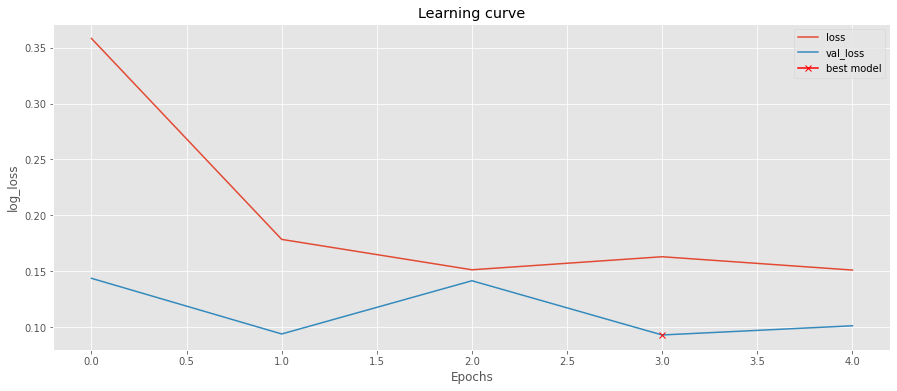

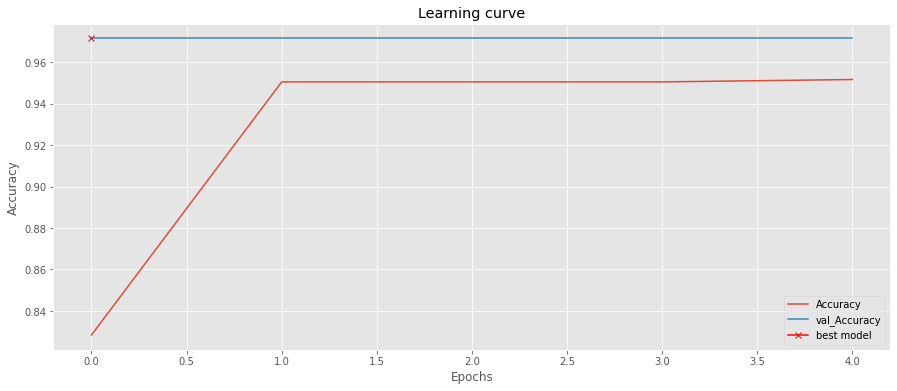

In [ ]:
plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["loss"], label="loss")
plt.plot(results.history["val_loss"], label="val_loss")
plt.plot(np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("log_loss")
plt.legend();

plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["accuracy"], label="Accuracy")
plt.plot(results.history["val_accuracy"], label="val_Accuracy")
plt.plot(np.argmax(results.history["val_accuracy"]), np.max(results.history["val_accuracy"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();

Inference

In [ ]:
model.load_weights('model-ResUnet.h5')

In [ ]:
model.evaluate(X_test, y_test, verbose=1)

1/1 [==============================] - 4s 4s/step - loss: 0.0929 - accuracy: 0.9714 - auc: 0.8980 - sensitivity_at_specificity: 0.9429 - specificity_at_sensitivity: 0.9661


[0.09287723153829575,
 0.9713988900184631,
 0.8980405330657959,
 0.9429479241371155,
 0.9661478996276855]

In [ ]:
# Predict on train, val and test
preds_train = model.predict(X_train, verbose=1)
preds_val = model.predict(X_test, verbose=1)

1/1 [==============================] - 4s 4s/step


In [ ]:
# Threshold predictions
preds_train_t = (preds_train > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5).astype(np.uint8)

In [ ]:
def plot_sample(X, y, preds, binary_preds, ix=None):
    """Function to plot the results"""
    if ix is None:
        ix = random.randint(0, len(X))

    has_mask = y[ix].max() > 0

    fig, ax = plt.subplots(1, 4, figsize=(20, 10))
    ax[0].imshow(X[ix, ..., 0], cmap='seismic')
    if has_mask:
        ax[0].contour(y[ix].squeeze(), colors='k', levels=[0.5])
    ax[0].set_title('Ground Image')
    ax[0].set_axis_off()

    ax[1].imshow(y[ix].squeeze())
    ax[1].set_title('Mask Image')
    ax[1].set_axis_off()

    ax[2].imshow(preds[ix].squeeze(), vmin=0, vmax=1)
    if has_mask:
        ax[2].contour(y[ix].squeeze(), colors='k', levels=[0.5])
    ax[2].set_title('Image Predicted')
    ax[2].set_axis_off()


    ax[3].imshow(binary_preds[ix].squeeze(), vmin=0, vmax=1)
    if has_mask:
        ax[3].contour(y[ix].squeeze(), colors='k', levels=[0.5])
    ax[3].set_title('Image Predicted binary');
    ax[3].set_axis_off()

Predictions on training set

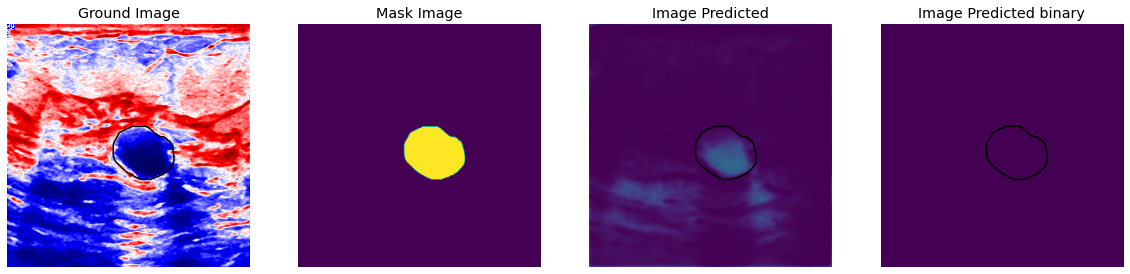

In [ ]:
# Check if training data looks all right
plot_sample(X_train, y_train, preds_train, preds_train_t, ix=14)

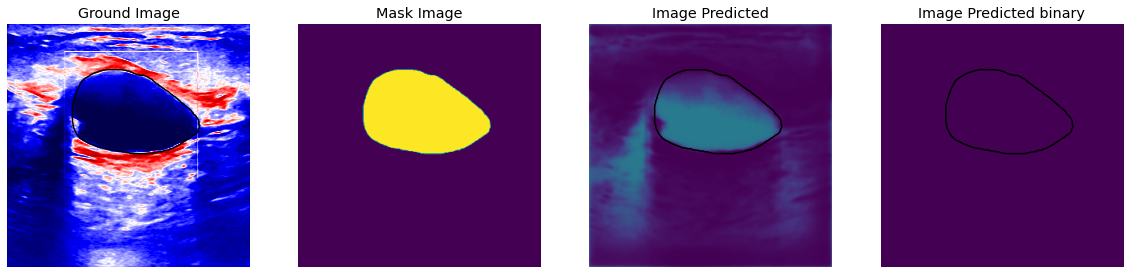

In [ ]:
plot_sample(X_train, y_train, preds_train, preds_train_t)

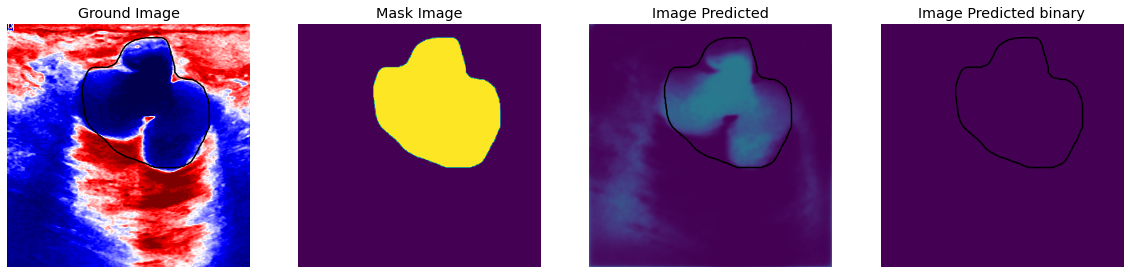

In [ ]:
plot_sample(X_train, y_train, preds_train, preds_train_t)

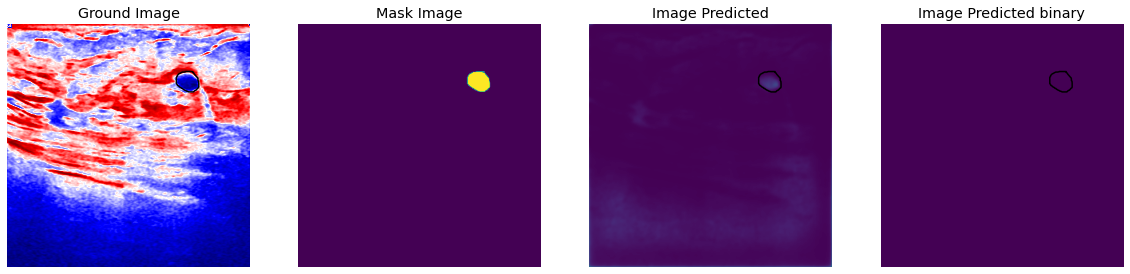

In [ ]:
plot_sample(X_train, y_train, preds_train, preds_train_t)

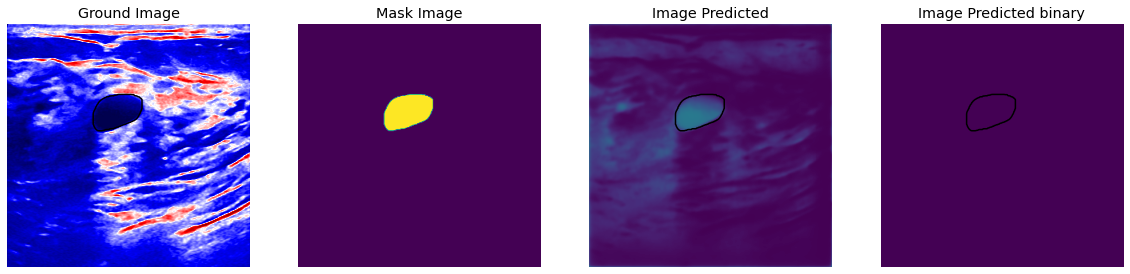

In [ ]:
plot_sample(X_train, y_train, preds_train, preds_train_t)

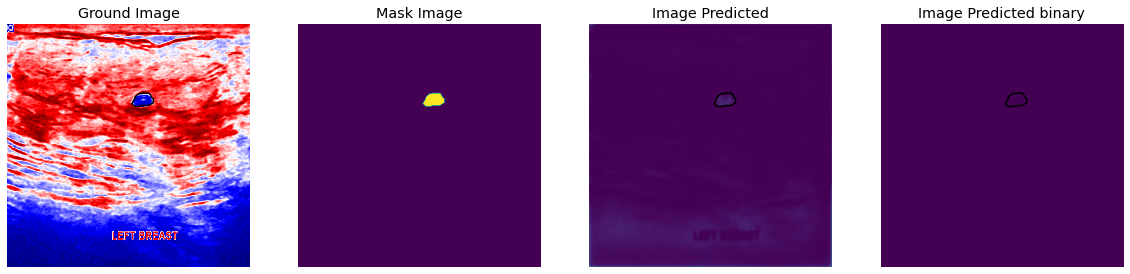

In [ ]:
plot_sample(X_train, y_train, preds_train, preds_train_t)

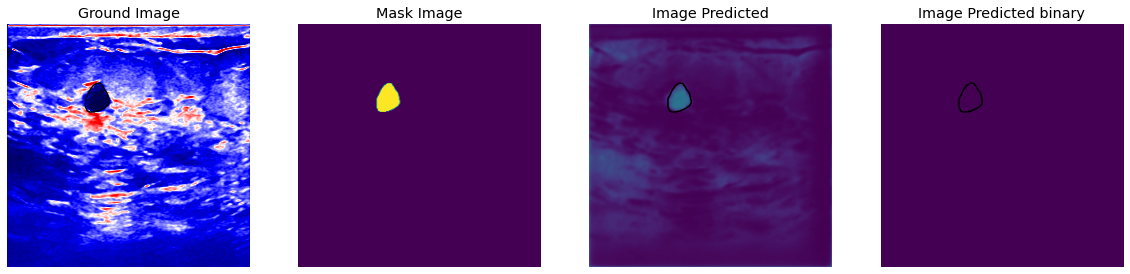

In [ ]:
plot_sample(X_train, y_train, preds_train, preds_train_t)

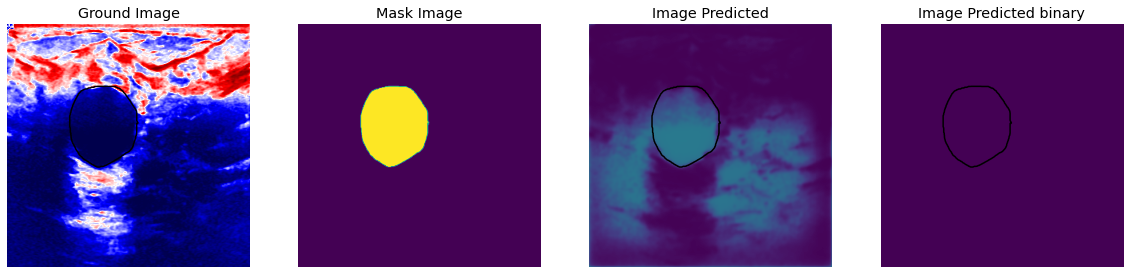

In [ ]:
plot_sample(X_train, y_train, preds_train, preds_train_t)

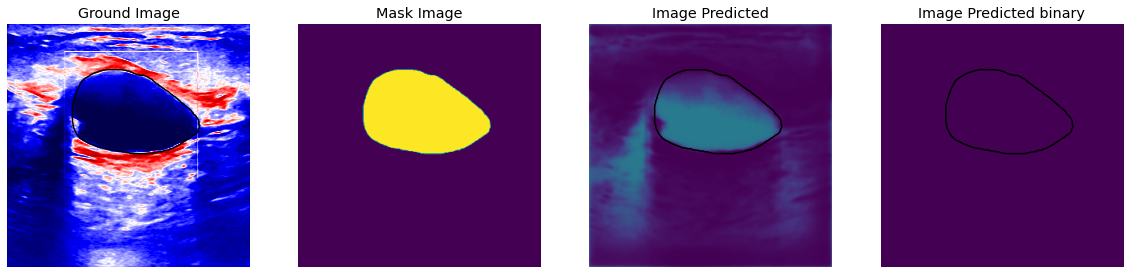

In [ ]:
plot_sample(X_train, y_train, preds_train, preds_train_t)

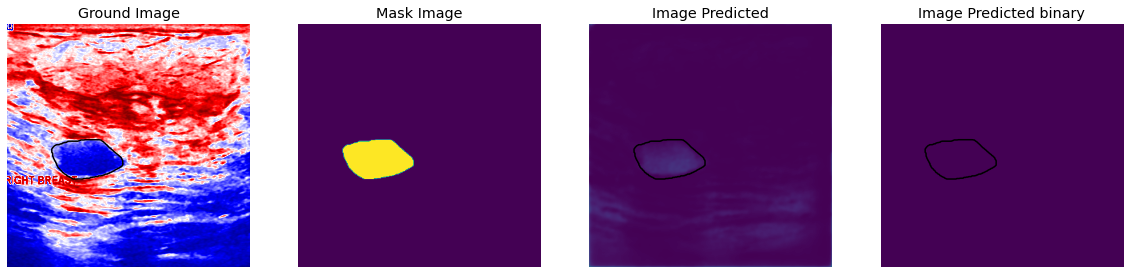

In [ ]:
plot_sample(X_train, y_train, preds_train, preds_train_t)